# Week 2: Fixed-$k$ Development Baseline Response Surface
**Project:** Query-Conditioned Evidence Allocation (QCCA)  
**Parent Framework:** SARA — Selective and Adaptive Retrieval-augmented Generation with Context Compression  
**Benchmark:** QASPER Development Set (231 questions across 86 papers)  
**Hardware:** NVIDIA TITAN RTX 24 GB  

---

### Scientific Objective
Week 2 establishes the empirical baseline quality/efficiency curve for static evidence allocation across:
$$k \in \{0, 2, 4, 5, 6, 8, 10\}$$
for all 231 development questions ($231 \times 7 = 1{,}617$ total evaluation points).

### Experimental Protocol & Structural Contracts
1. **Ordering Contract:** For each query, candidate passages $d_1, \dots, d_{10}$ are identical and in exact BM25 retrieval order across all $k$.
   - Ranks $1 \dots k$: natural language text context
   - Ranks $k+1 \dots 10$: compressed via precomputed SFR embeddings at `<COMPRESS>` positions
2. **Model Assignments:**
   - $k \in \{0, 2, 4, 5, 6, 8\}$: Evaluated with SARA (`sara_qasper_proj_lr5e4_seed42`)
   - $k = 10$: Evaluated with Standard RAG baseline (`rag_qasper_lora_r16_seed42`)
3. **Sequential Execution Protocol:** Due to the 24 GB GPU budget, SFR embeddings are precomputed and cached to disk first. SFR is unloaded before Mistral is loaded.
4. **Notebook Design:** Every stage can be run directly from this notebook on either:
   - A **Smoke Test subset** (e.g. 3 questions $\to$ 21 evaluations) to verify correctness
   - The **Complete Set** (231 questions $\to$ 1,617 evaluations)
   - Results, CSV tables, JSON metadata, and Pareto plots are dynamically displayed inline.


## 1. Environment & Path Setup
Initialize paths, verify the Python environment, check CUDA availability, and reset GPU memory stats.


In [1]:
import os
import sys
import gc
import json
import time
import subprocess
from pathlib import Path
from typing import Dict, List, Any, Optional

import torch
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Verify repository root and python path
REPO_ROOT = Path(".").resolve()
if not (REPO_ROOT / "configs" / "week2" / "sweep_config.yaml").exists():
    # If run from inside notebooks/week2
    REPO_ROOT = REPO_ROOT.parents[1]

SARA_ROOT = REPO_ROOT / "Baselines" / "SARA-main"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(SARA_ROOT) not in sys.path:
    sys.path.insert(0, str(SARA_ROOT))

# Ensure SARA module resolution works alongside workspace src
import src
if hasattr(src, "__path__") and str(SARA_ROOT / "src") not in src.__path__:
    src.__path__.append(str(SARA_ROOT / "src"))

# Set environment variables for child processes (preserving REPO_ROOT on PYTHONPATH)
ENV = os.environ.copy()
ENV["PYTHONPATH"] = str(REPO_ROOT)

print(f"Workspace Root : {REPO_ROOT}")
print(f"SARA Root      : {SARA_ROOT}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device     : {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Allocated VRAM : {torch.cuda.memory_allocated() / 1e9:.2f} GB")


Workspace Root : /home/gunavenkat/Downloads/CS787-RAG-Project
SARA Root      : /home/gunavenkat/Downloads/CS787-RAG-Project/Baselines/SARA-main
PyTorch Version: 2.14.0+cu130
CUDA Available : True
GPU Device     : NVIDIA TITAN RTX
Total VRAM     : 25.18 GB
Allocated VRAM : 0.00 GB


## 2. Configuration & Execution Knobs
Load `configs/week2/sweep_config.yaml`.
Configure whether to run **Smoke Test Mode** or **Full Dataset Mode** for subsequent cells.


In [2]:
config_path = REPO_ROOT / "configs" / "week2" / "sweep_config.yaml"
with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# ==============================================================================
# EXECUTION CONTROLS
# Set RUN_SMOKE_TEST = True to test on a 3-question subset (fast verification)
# Set RUN_SMOKE_TEST = False to run the complete 231-question development sweep
# ==============================================================================
RUN_SMOKE_TEST = True
SMOKE_TEST_LIMIT = 3

QUESTION_LIMIT = SMOKE_TEST_LIMIT if RUN_SMOKE_TEST else None

# Stage Execution Flags
# If you have already cached embeddings or run sweeps, you can set these to False
# to inspect existing results, or True to re-run from scratch.
RUN_STAGE_1 = False  # Set to True to re-run BM25 retrieval + SFR caching
RUN_STAGE_2 = False  # Set to True to re-run Fixed-k SARA/RAG inference sweep
RUN_STAGE_3 = True   # Always recommended: regenerates summary tables and plots

print("=== EXPERIMENT CONFIGURATION ===")
print(f"Mode                : {'SMOKE TEST (' + str(SMOKE_TEST_LIMIT) + ' questions)' if RUN_SMOKE_TEST else 'FULL EVALUATION (231 questions)'}")
print(f"Random Seed         : {config.get('seed', 42)}")
print(f"Fixed-k Grid        : {config.get('k_values', [0, 2, 4, 5, 6, 8, 10])}")
print(f"Top-N Passages      : {config.get('n_retrieved', 10)}")
print(f"Max New Tokens      : {config['generation']['max_new_tokens']}")
print(f"Do Sample           : {config['generation']['do_sample']}")
print(f"SARA Checkpoint     : {config['models']['sara_checkpoint']}")
print(f"RAG Checkpoint      : {config['models']['rag_checkpoint']}")


=== EXPERIMENT CONFIGURATION ===
Mode                : SMOKE TEST (3 questions)
Random Seed         : 42
Fixed-k Grid        : [0, 2, 4, 5, 6, 8, 10]
Top-N Passages      : 10
Max New Tokens      : 64
Do Sample           : False
SARA Checkpoint     : Baselines/SARA-main/checkpoints/finetune/sara_qasper_proj_lr5e4_seed42
RAG Checkpoint      : Baselines/SARA-main/checkpoints/finetune/rag_qasper_lora_r16_seed42


## 3. Unit Test Verification
Run the Week-2 test suite (`tests/week2/`) to verify feature extraction boundary conditions, embedding tensor caching contracts, $k$-mapping consistency, and output record schemas.


In [3]:
test_cmd = [sys.executable, "-m", "pytest", str(REPO_ROOT / "tests" / "week2"), "-v"]
print("Running Week-2 unit test suite...")
res = subprocess.run(test_cmd, capture_output=True, text=True, cwd=str(REPO_ROOT), env=ENV)
print(res.stdout)
if res.returncode != 0:
    print(res.stderr)
    raise RuntimeError("Unit tests failed! Please fix failing tests before running experiments.")
else:
    print("All unit tests passed successfully!")


Running Week-2 unit test suite...


============================= test session starts ==============================
platform linux -- Python 3.11.16, pytest-9.1.1, pluggy-1.6.0 -- /home/gunavenkat/sara_env/bin/python
cachedir: .pytest_cache
rootdir: /home/gunavenkat/Downloads/CS787-RAG-Project
plugins: langsmith-0.14.1, anyio-4.15.1
collecting ... collected 16 items

tests/week2/test_embedding_cache.py::test_mock_embedding_cache_structure PASSED [  6%]
tests/week2/test_embedding_cache.py::test_slice_compressed_embeddings PASSED [ 12%]
tests/week2/test_feature_extractor.py::test_normal_positive_scores PASSED [ 18%]
tests/week2/test_feature_extractor.py::test_equal_scores PASSED          [ 25%]
tests/week2/test_feature_extractor.py::test_all_zero_scores PASSED       [ 31%]
tests/week2/test_feature_extractor.py::test_negative_scores PASSED       [ 37%]
tests/week2/test_feature_extractor.py::test_one_dominant_score PASSED    [ 43%]
tests/week2/test_feature_extractor.py::test_duplicated_scores PASSED     [ 50%]
tests/week2/t

## 4. Stage 1: BM25 Retrieval & SFR Embedding Caching
1. Executes BM25 retrieval over QASPER paper chunks, selecting top-10 passages per question.
2. Extracts distribution features ($\rho_1, \Delta_{12}, H_{\text{norm}}, N_{\text{high}}$) from BM25 scores.
3. Loads `Salesforce/SFR-Embedding-Mistral` in `bfloat16`, encodes all retrieved passages, and caches tensors to `results/week2/raw/dev_sfr_embeddings.pt`.
4. Deletes SFR and clears GPU VRAM completely before generation.


In [4]:
if RUN_STAGE_1:
    stage1_script = REPO_ROOT / "scripts" / "week2" / "01_cache_embeddings.sh"
    cmd = [str(stage1_script)]
    if QUESTION_LIMIT is not None:
        cmd.append(str(QUESTION_LIMIT))

    print(f"Executing Stage 1: {' '.join(cmd)}")
    t0 = time.time()
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, cwd=str(REPO_ROOT), env=ENV)
    for line in iter(p.stdout.readline, ""):
        print(line, end="")
    p.stdout.close()
    p.wait()
    if p.returncode != 0:
        raise RuntimeError(f"Stage 1 failed with exit code {p.returncode}")
    print(f"Stage 1 completed in {time.time() - t0:.2f}s.")
else:
    print("Using existing cached embeddings in results/week2/raw/dev_sfr_embeddings.pt.")


Using existing cached embeddings in results/week2/raw/dev_sfr_embeddings.pt.


### Verify Cached Embeddings & VRAM Release
Inspect the generated `.pt` cache and confirm the VRAM has been reclaimed.


In [5]:
cache_path = REPO_ROOT / "results" / "week2" / "raw" / "dev_sfr_embeddings.pt"
assert cache_path.exists(), f"Embedding cache not found at {cache_path}"

cache = torch.load(cache_path, map_location="cpu")
print("=== SFR CACHE METADATA ===")
for k, v in cache["metadata"].items():
    print(f"  {k:25s}: {v}")

print(f"Total questions in cache: {len(cache['embeddings'])}")
sample_qid = list(cache["embeddings"].keys())[0]
sample_tensor = cache["embeddings"][sample_qid]
print(f"Sample QID: {sample_qid} | Tensor Shape: {sample_tensor.shape} | Dtype: {sample_tensor.dtype}")

if torch.cuda.is_available():
    print(f"Current GPU VRAM Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB (Should be ~0.0 GB)")


=== SFR CACHE METADATA ===
  model_name               : Salesforce/SFR-Embedding-Mistral
  dtype                    : bfloat16
  dim                      : 4096
  num_questions            : 3
  passages_per_question    : 10
  encoding_time_seconds    : 18.592189073562622
  timestamp                : 2026-09-29 22:43:32
Total questions in cache: 3
Sample QID: 1912 | Tensor Shape: torch.Size([10, 4096]) | Dtype: torch.bfloat16
Current GPU VRAM Allocated: 0.00 GB (Should be ~0.0 GB)


## 5. Retrieval Distribution Features Inspection
Inspect the features extracted from BM25 scores:
- **Top-1 concentration:** $\rho_1 = \frac{s'_1}{\sum_i s'_i + \epsilon}$
- **Top-1/Top-2 margin:** $\Delta_{12} = \frac{s'_1 - s'_2}{s'_1 + \epsilon}$
- **Normalized entropy:** $H_{\text{norm}} = -\frac{\sum_i p_i \log p_i}{\log(10)}$
- **High-score count:** $N_{\text{high}} = \sum_i \mathbf{1}_{\{s'_i \ge 0.8 s'_1\}}$


In [6]:
feat_path = REPO_ROOT / "results" / "week2" / "processed" / "dev_retrieval_features.jsonl"
assert feat_path.exists(), f"Features file not found at {feat_path}"

features = []
with open(feat_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            features.append(json.loads(line))

df_features = pd.DataFrame(features)
print(f"Loaded {len(df_features)} feature records.")
display(df_features.head(10))

print("\nFeature Summary Statistics:")
display(df_features[["rho_1", "delta_12", "entropy_normalized", "query_token_length", "n_high"]].describe())


Loaded 3 feature records.


,question_id,paper_id,rho_1,delta_12,entropy,entropy_normalized,query_token_length,n_high
0,1912,638,1.000000,1.000000,0.000000,0.000000,8,1
1,2201,798,0.199186,0.371415,2.235207,0.970738,13,1
2,883,254,0.344720,0.325243,1.820532,0.790647,4,1



Feature Summary Statistics:


,rho_1,delta_12,entropy_normalized,query_token_length,n_high
count,3.000000,3.000000,3.000000,3.000000,3.0
mean,0.514635,0.565553,0.587128,8.333333,1.0
std,0.426590,0.376950,0.516380,4.509250,0.0
min,0.199186,0.325243,0.000000,4.000000,1.0
25%,0.271953,0.348329,0.395323,6.000000,1.0
50%,0.344720,0.371415,0.790647,8.000000,1.0
75%,0.672360,0.685708,0.880692,10.500000,1.0
max,1.000000,1.000000,0.970738,13.000000,1.0


## 6. Stage 2: Fixed-$k$ Development Sweep Inference
Executes deterministic generation ($max\_new\_tokens=64, do\_sample=False$) across all $k \in \{0, 2, 4, 5, 6, 8, 10\}$:
- Evaluates SARA checkpoint for $k < 10$ with cached SFR embeddings
- Evaluates Standard RAG checkpoint for $k = 10$ with full text
- Resumable: automatically skips previously completed $(question\_id, k)$ pairs


In [7]:
if RUN_STAGE_2:
    stage2_script = REPO_ROOT / "scripts" / "week2" / "02_run_fixed_k_sweep.sh"
    cmd = [str(stage2_script)]
    if QUESTION_LIMIT is not None:
        cmd.append(str(QUESTION_LIMIT))

    print(f"Executing Stage 2: {' '.join(cmd)}")
    t0 = time.time()
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, cwd=str(REPO_ROOT), env=ENV)
    for line in iter(p.stdout.readline, ""):
        print(line, end="")
    p.stdout.close()
    p.wait()
    if p.returncode != 0:
        raise RuntimeError(f"Stage 2 failed with exit code {p.returncode}")
    print(f"Stage 2 completed in {time.time() - t0:.2f}s.")
else:
    print("Using existing evaluation matrix in results/week2/raw/dev_fixed_k_matrix.jsonl.")


Using existing evaluation matrix in results/week2/raw/dev_fixed_k_matrix.jsonl.


## 7. Qualitative Prediction Inspection across $k$
Inspect predictions across different evidence allocations for representative development queries.


In [8]:
matrix_file = REPO_ROOT / "results" / "week2" / "raw" / "dev_fixed_k_matrix.jsonl"
records = []
with open(matrix_file, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

df_matrix = pd.DataFrame(records)
print(f"Total evaluated records in matrix: {len(df_matrix)}")

# Display qualitative comparison for a sample question
sample_qids = df_matrix["question_id"].unique()[:2]
for qid in sample_qids:
    q_df = df_matrix[df_matrix["question_id"] == qid].sort_values("k")
    gold = q_df["gold_answers"].iloc[0]
    print(f"\n==================================================================================")
    print(f"Question ID: {qid}")
    print(f"Gold Answer: {gold}")
    print(f"==================================================================================")
    for _, row in q_df.iterrows():
        print(f"k={row['k']:2d} | CtxTok={row['input_tokens']:4d} | F1={row['token_f1']:5.2f} | EM={row['exact_match']:3.1f} | Lat={row['generation_latency']:5.2f}s | Method={row['method']}")
        print(f"   Prediction: {row['prediction'][:120]}")


Total evaluated records in matrix: 21

Question ID: 1912
Gold Answer: ['WN18 and FB15k']
k= 0 | CtxTok= 137 | F1= 0.00 | EM=0.0 | Lat= 0.62s | Method=sara
   Prediction: 10
k= 2 | CtxTok= 445 | F1= 0.00 | EM=0.0 | Lat= 3.48s | Method=sara
   Prediction: Freebase, WikiMovies, DBpedia, YAGO, NELL, NELL-1000, NELL-10000, NELL-100000, NELL-1000000, NELL-100
k= 4 | CtxTok= 435 | F1= 0.00 | EM=0.0 | Lat= 2.61s | Method=sara
   Prediction: Freebase, WikiMovies, DBpedia, YAGO, NELL, ConceptNet, WordNet, SenticNet, and SenticNet-350
k= 5 | CtxTok= 430 | F1= 0.00 | EM=0.0 | Lat= 2.60s | Method=sara
   Prediction: Freebase, WikiMovies, DBpedia, YAGO, NELL, ConceptNet, WordNet, SenticNet, and SenticNet-353
k= 6 | CtxTok= 425 | F1= 0.00 | EM=0.0 | Lat= 3.44s | Method=sara
   Prediction: Freebase, WikiMovies, WikiMovies-100M, WikiMovies-100M-100K, WikiMovies-100M-100K-100K, WikiMovies-1
k= 8 | CtxTok= 415 | F1= 0.50 | EM=0.0 | Lat= 2.35s | Method=sara
   Prediction: Freebase, WikiKG, FB15k, FB15k-23

## 8. Stage 3: Metrics Aggregation & Baseline Selection
1. Computes mean Token F1, Exact Match, ROUGE-L, and Context Token Reductions relative to $k=10$.
2. Generates `results/week2/processed/dev_fixed_k_summary.csv` and `dev_per_query_k_matrix.csv`.
3. Selects the best static development baseline $k_{\text{dev}}^* = \arg\max_k \text{Mean F1}(k)$.
4. Produces all 8 publication-quality Pareto analysis plots.


In [9]:
if RUN_STAGE_3:
    stage3_script = REPO_ROOT / "scripts" / "week2" / "03_generate_summary.sh"
    print(f"Executing Stage 3: {stage3_script}")
    res = subprocess.run([str(stage3_script)], capture_output=True, text=True, cwd=str(REPO_ROOT), env=ENV)
    print(res.stdout)
    if res.returncode != 0:
        print(res.stderr)
        raise RuntimeError("Stage 3 summary aggregation failed.")


Executing Stage 3: /home/gunavenkat/Downloads/CS787-RAG-Project/scripts/week2/03_generate_summary.sh


STAGE 3: METRICS AGGREGATION & PARETO PLOTTING
Start Time   : 2026-09-29 22:56:51
Workspace    : /home/gunavenkat/Downloads/CS787-RAG-Project
Python       : /home/gunavenkat/sara_env/bin/python
Config       : /home/gunavenkat/Downloads/CS787-RAG-Project/configs/week2/sweep_config.yaml
Loaded 21 records from: /home/gunavenkat/Downloads/CS787-RAG-Project/results/week2/raw/dev_fixed_k_matrix.jsonl
Saved summary table to: /home/gunavenkat/Downloads/CS787-RAG-Project/results/week2/processed/dev_fixed_k_summary.csv
Saved per-query k-matrix to: /home/gunavenkat/Downloads/CS787-RAG-Project/results/week2/processed/dev_per_query_k_matrix.csv
Saved best static baseline metadata to: /home/gunavenkat/Downloads/CS787-RAG-Project/results/week2/processed/best_static_baseline.json
Generated 8 publication-quality plots in: /home/gunavenkat/Downloads/CS787-RAG-Project/results/week2/plots

FIXED-K DEVELOPMENT RESPONSE SURFACE SUMMARY
 k method  n_questions  mean_f1  std_f1  mean_em  mean_rouge_l  mean_con

### Development Set Summary Table
Inspect the fixed-$k$ response surface summary:


In [10]:
summary_csv = REPO_ROOT / "results" / "week2" / "processed" / "dev_fixed_k_summary.csv"
df_summary = pd.read_csv(summary_csv)
print("=== FIXED-k DEVELOPMENT RESPONSE SURFACE SUMMARY ===")
display(df_summary)

# Display Best Static Baseline Metadata
baseline_json = REPO_ROOT / "results" / "week2" / "processed" / "best_static_baseline.json"
with open(baseline_json, "r") as f:
    best_meta = json.load(f)

print("\n=== BEST STATIC BASELINE (k_dev*) ===")
for k, v in best_meta.items():
    print(f"  {k:26s}: {v}")


=== FIXED-k DEVELOPMENT RESPONSE SURFACE SUMMARY ===


,k,method,n_questions,mean_f1,std_f1,mean_em,mean_rouge_l,mean_context_tokens,mean_generated_tokens,context_reduction_pct,mean_gen_latency_sec,mean_synthesized_total_latency_sec
0,0,sara,3,0.0000,0.0000,0.0000,0.0,129.3,16.3,91.76,1.069,1.119
1,2,sara,3,0.4889,0.4286,0.0000,0.0,496.3,31.3,68.39,2.391,2.431
2,4,sara,3,0.4328,0.3752,0.0000,0.0,736.3,26.3,53.10,2.742,2.772
3,5,sara,3,0.4328,0.3752,0.0000,0.0,902.7,26.3,42.51,3.137,3.162
4,6,sara,3,0.3333,0.5774,0.3333,0.0,993.3,45.3,36.73,4.187,4.207
5,8,sara,3,0.5994,0.0879,0.0000,0.0,1291.3,24.0,17.75,4.135,4.146
6,10,rag,3,0.8222,0.1678,0.3333,0.0,1570.0,14.0,0.00,4.411,4.411



=== BEST STATIC BASELINE (k_dev*) ===
  best_static_k             : 10
  mean_f1                   : 0.8222
  exact_match               : 0.3333
  rouge_l                   : 0.0
  mean_context_tokens       : 1570.0
  context_reduction_pct     : 0.0
  selection_rule            : argmax_k Mean_F1_dev(k) with smaller-k tie-breaking
  evaluated_question_count  : 3
  seed                      : 42
  timestamp                 : 2026-09-29 22:56:52
  note                      : Development set static baseline. Test set untouched.


## 9. Publication-Quality Plots & Pareto Analysis
Visualizes the 8 generated Week-2 figures analyzing quality vs. token efficiency and inference latency.



--- Figure: Mean Token-F1 vs Allocation k (01_mean_token_f1_vs_k.png) ---


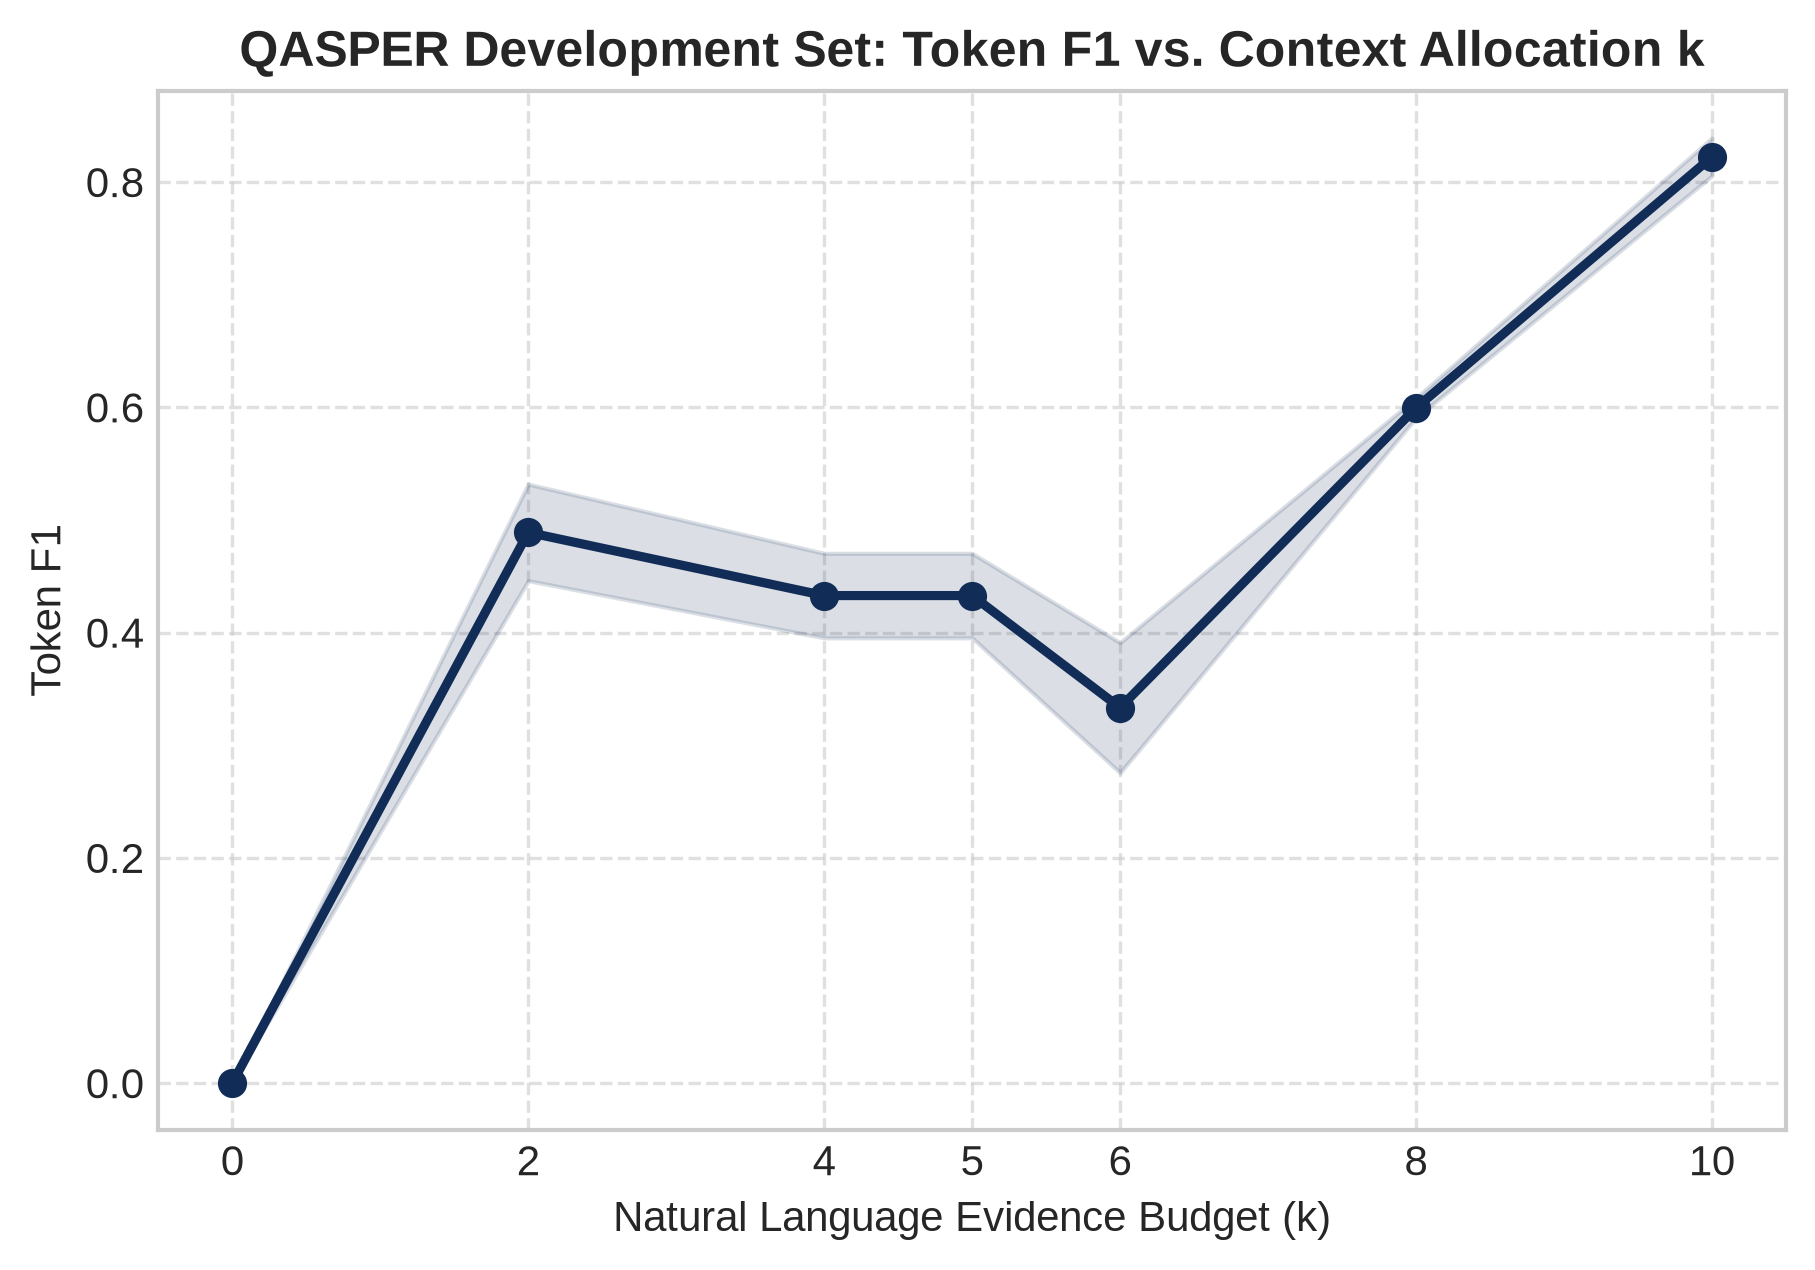


--- Figure: Mean Exact Match vs Allocation k (02_mean_em_vs_k.png) ---


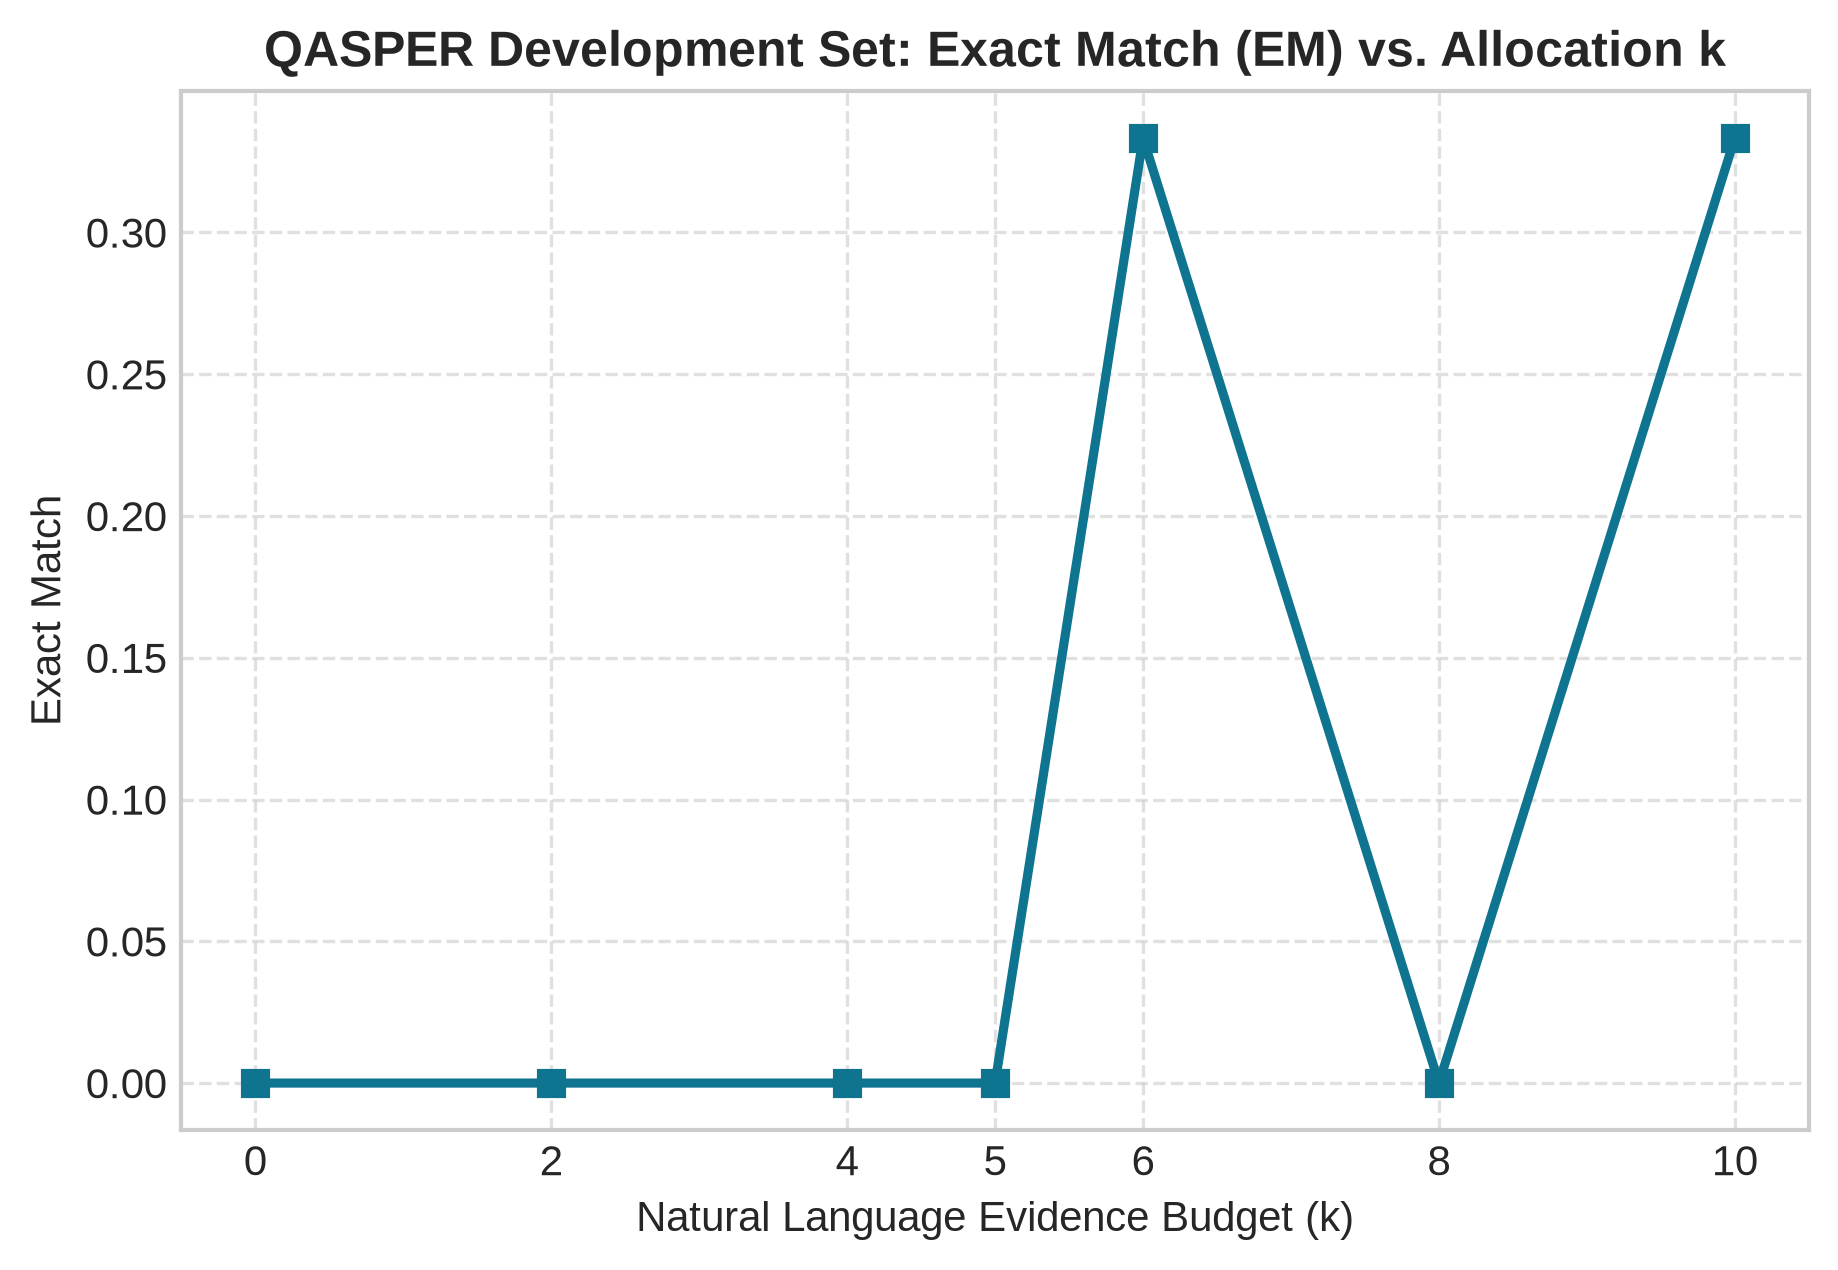


--- Figure: Mean ROUGE-L vs Allocation k (03_mean_rouge_l_vs_k.png) ---


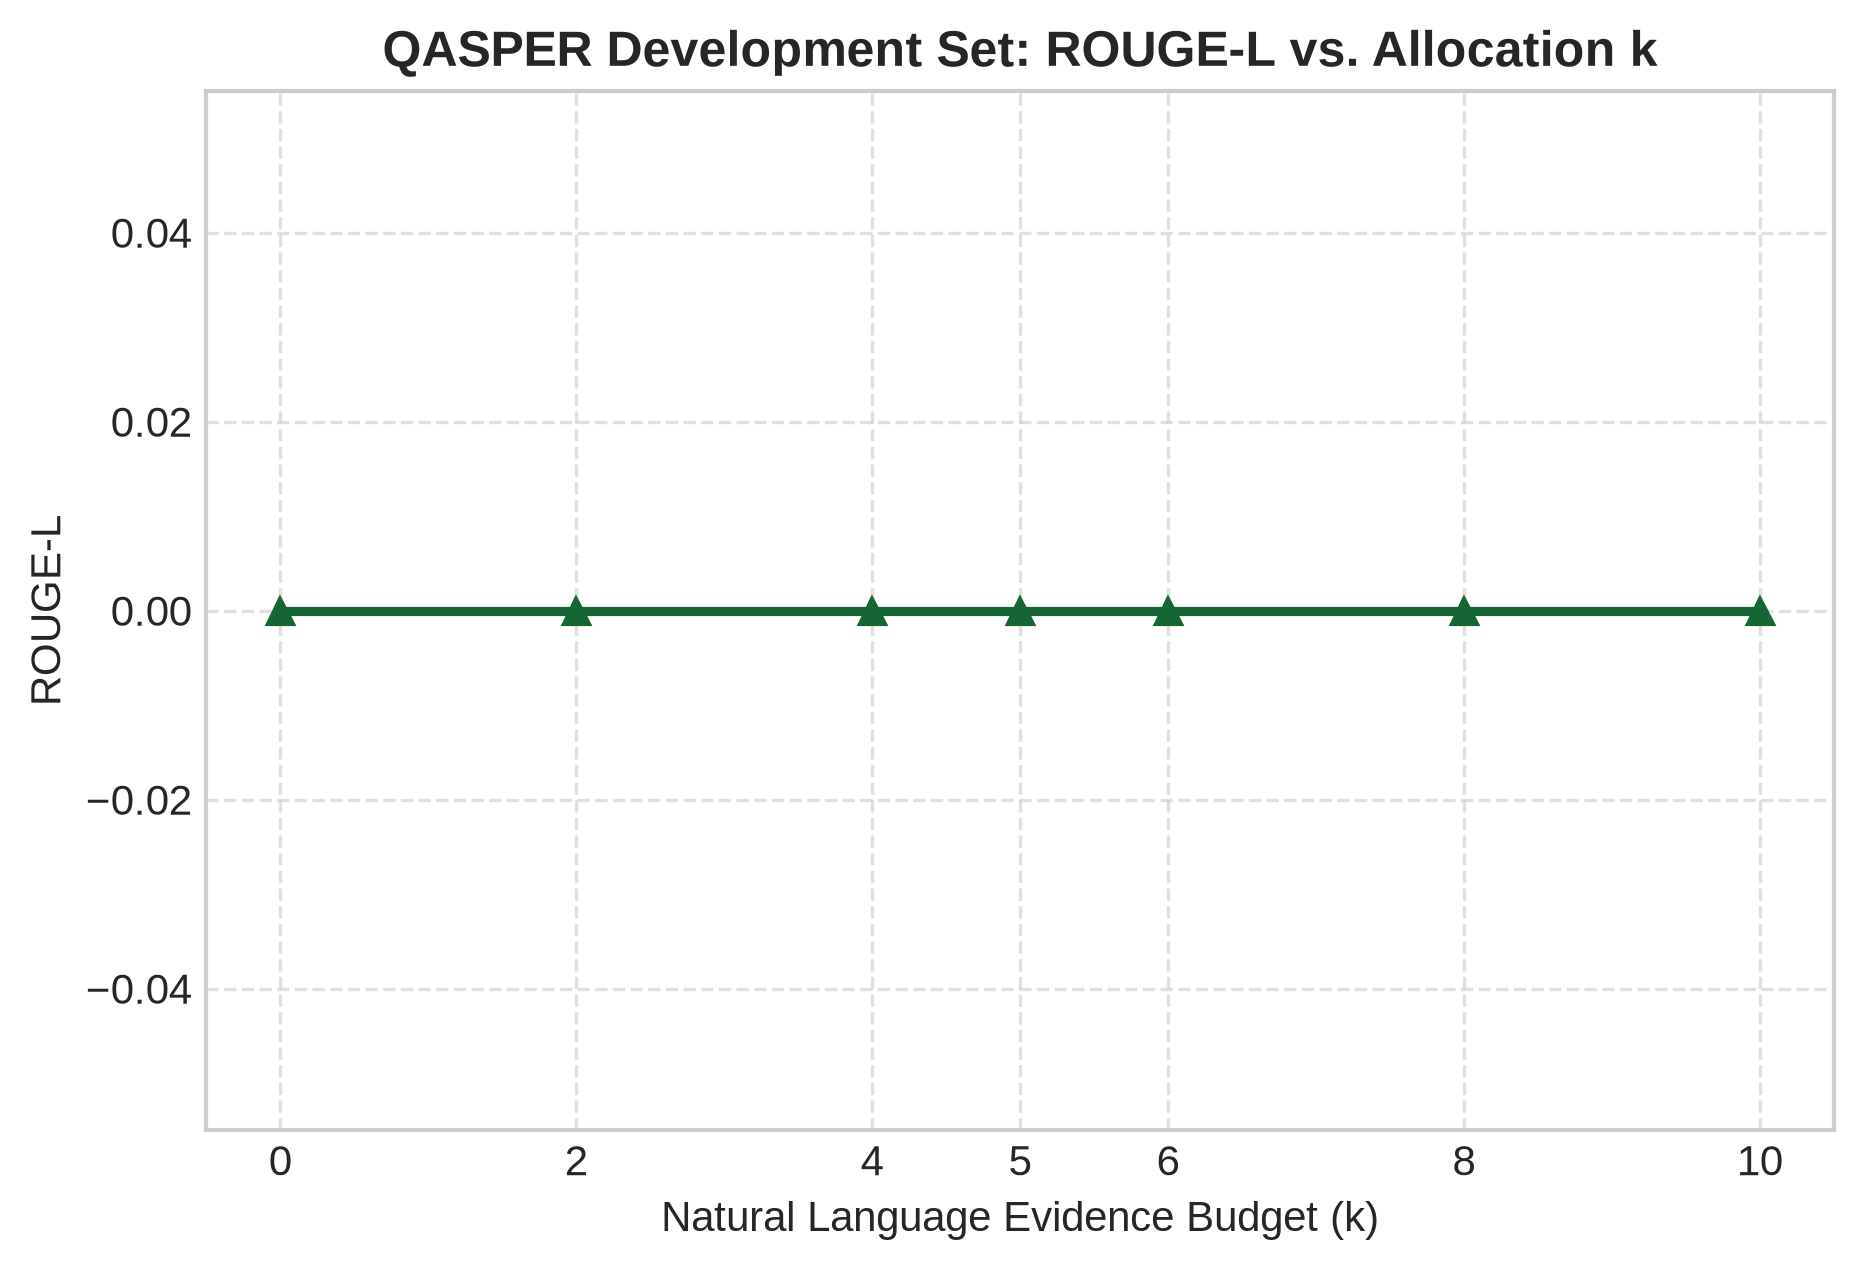


--- Figure: Mean Input Context Tokens vs Allocation k (04_mean_input_tokens_vs_k.png) ---


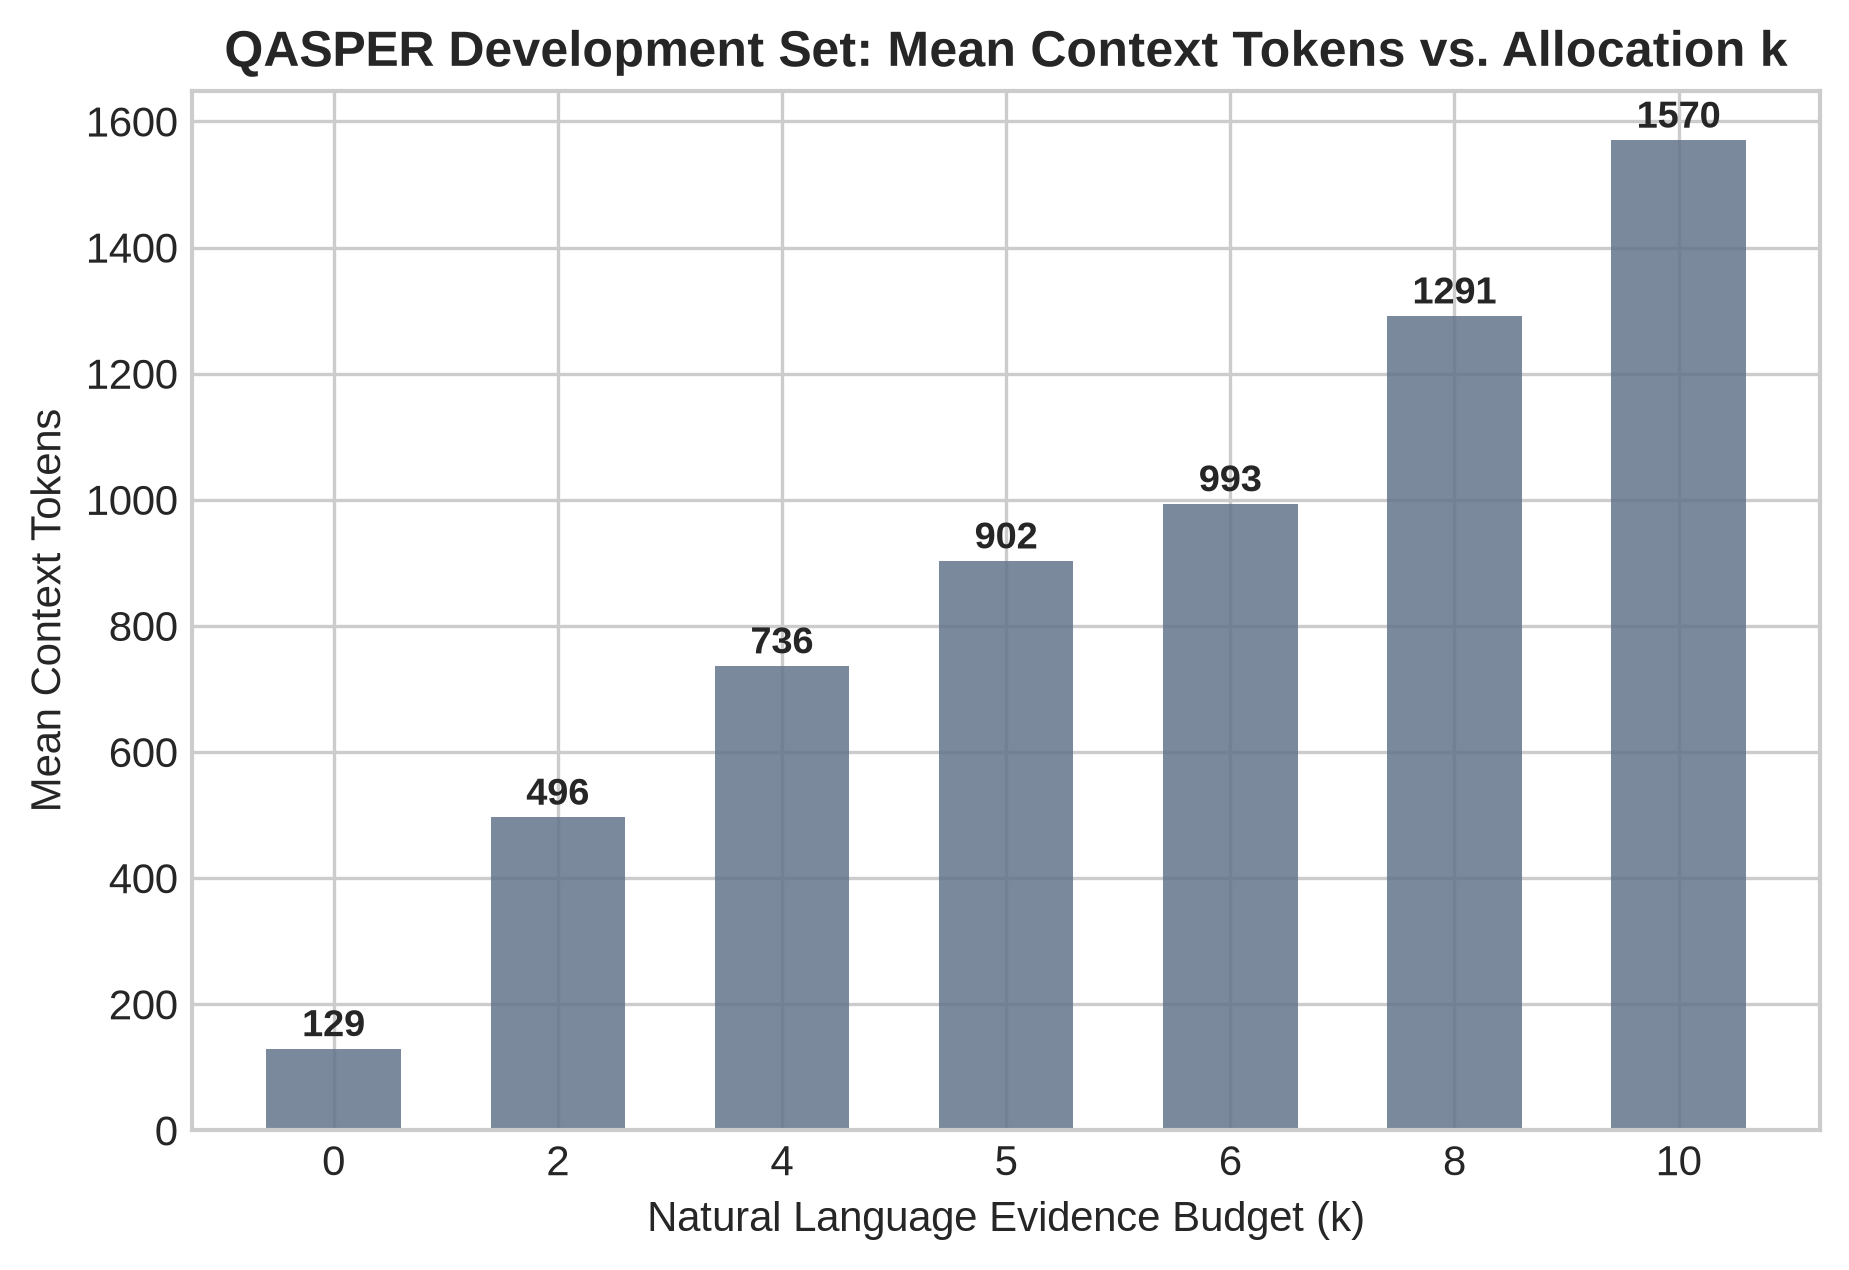


--- Figure: Pareto Curve: Token-F1 vs Context Tokens (05_token_f1_vs_context_tokens.png) ---


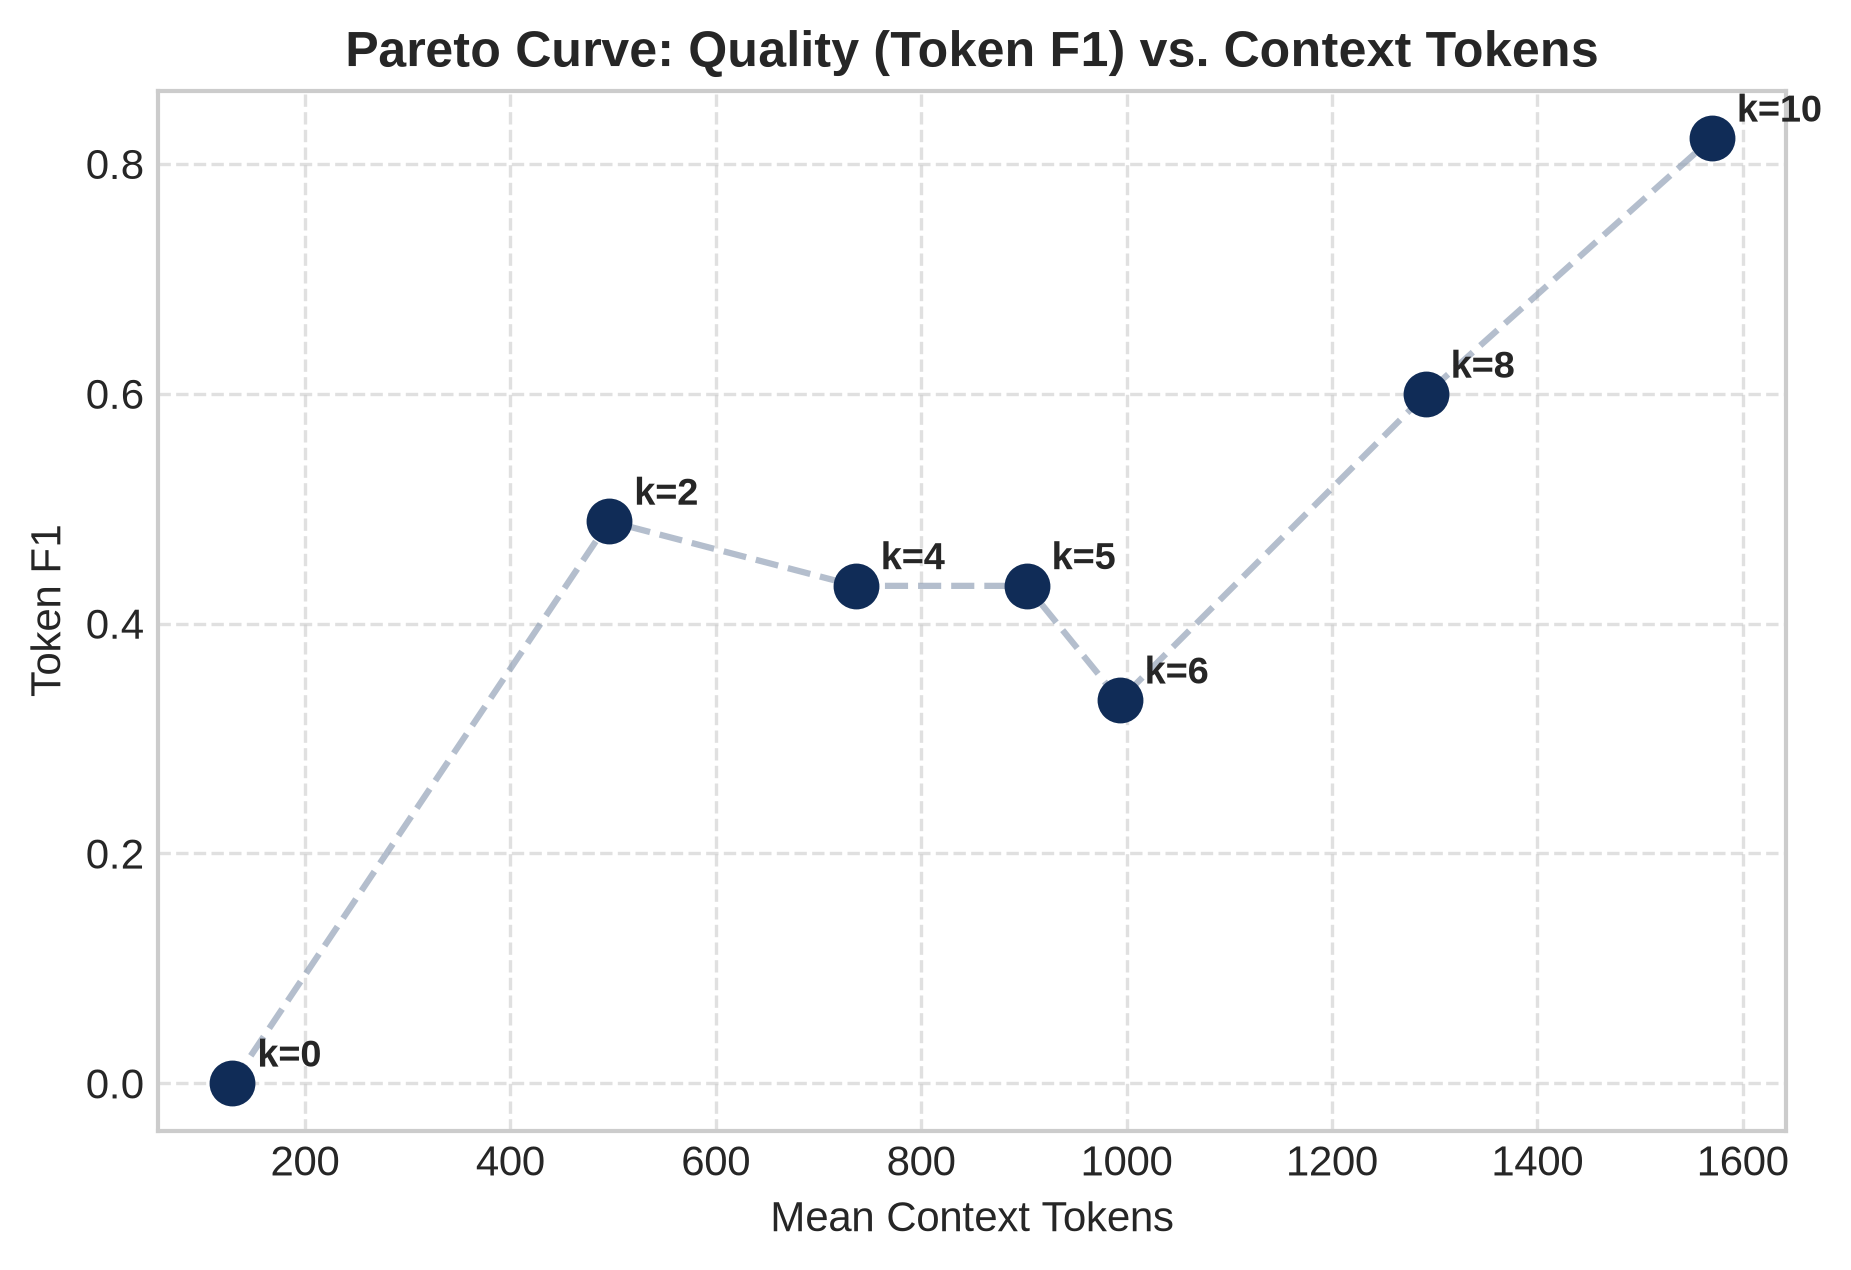


--- Figure: Token-F1 vs Measured Generation Latency (06_token_f1_vs_generation_latency.png) ---


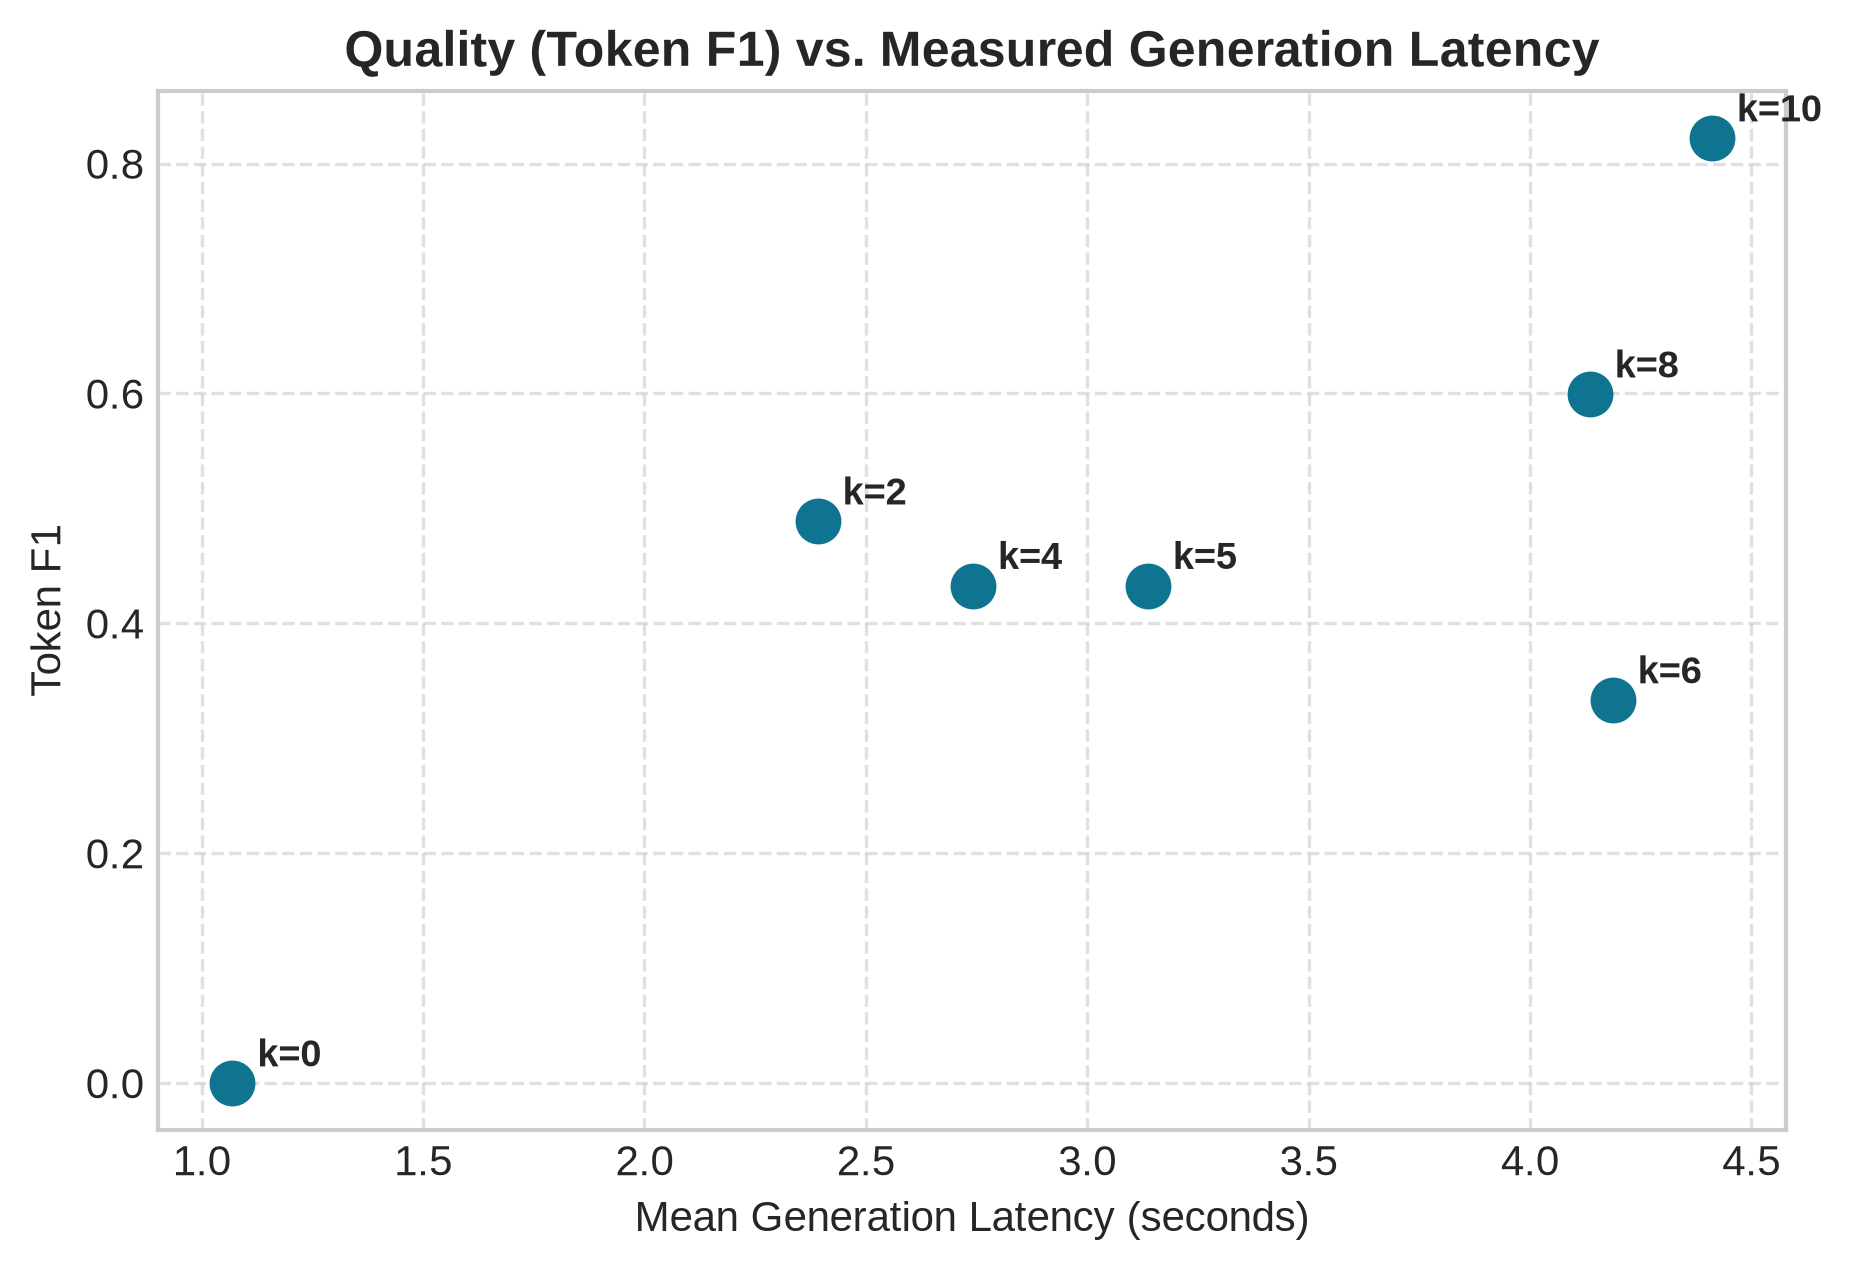


--- Figure: Token-F1 vs Synthesized Total Latency (07_token_f1_vs_synthesized_total_latency.png) ---


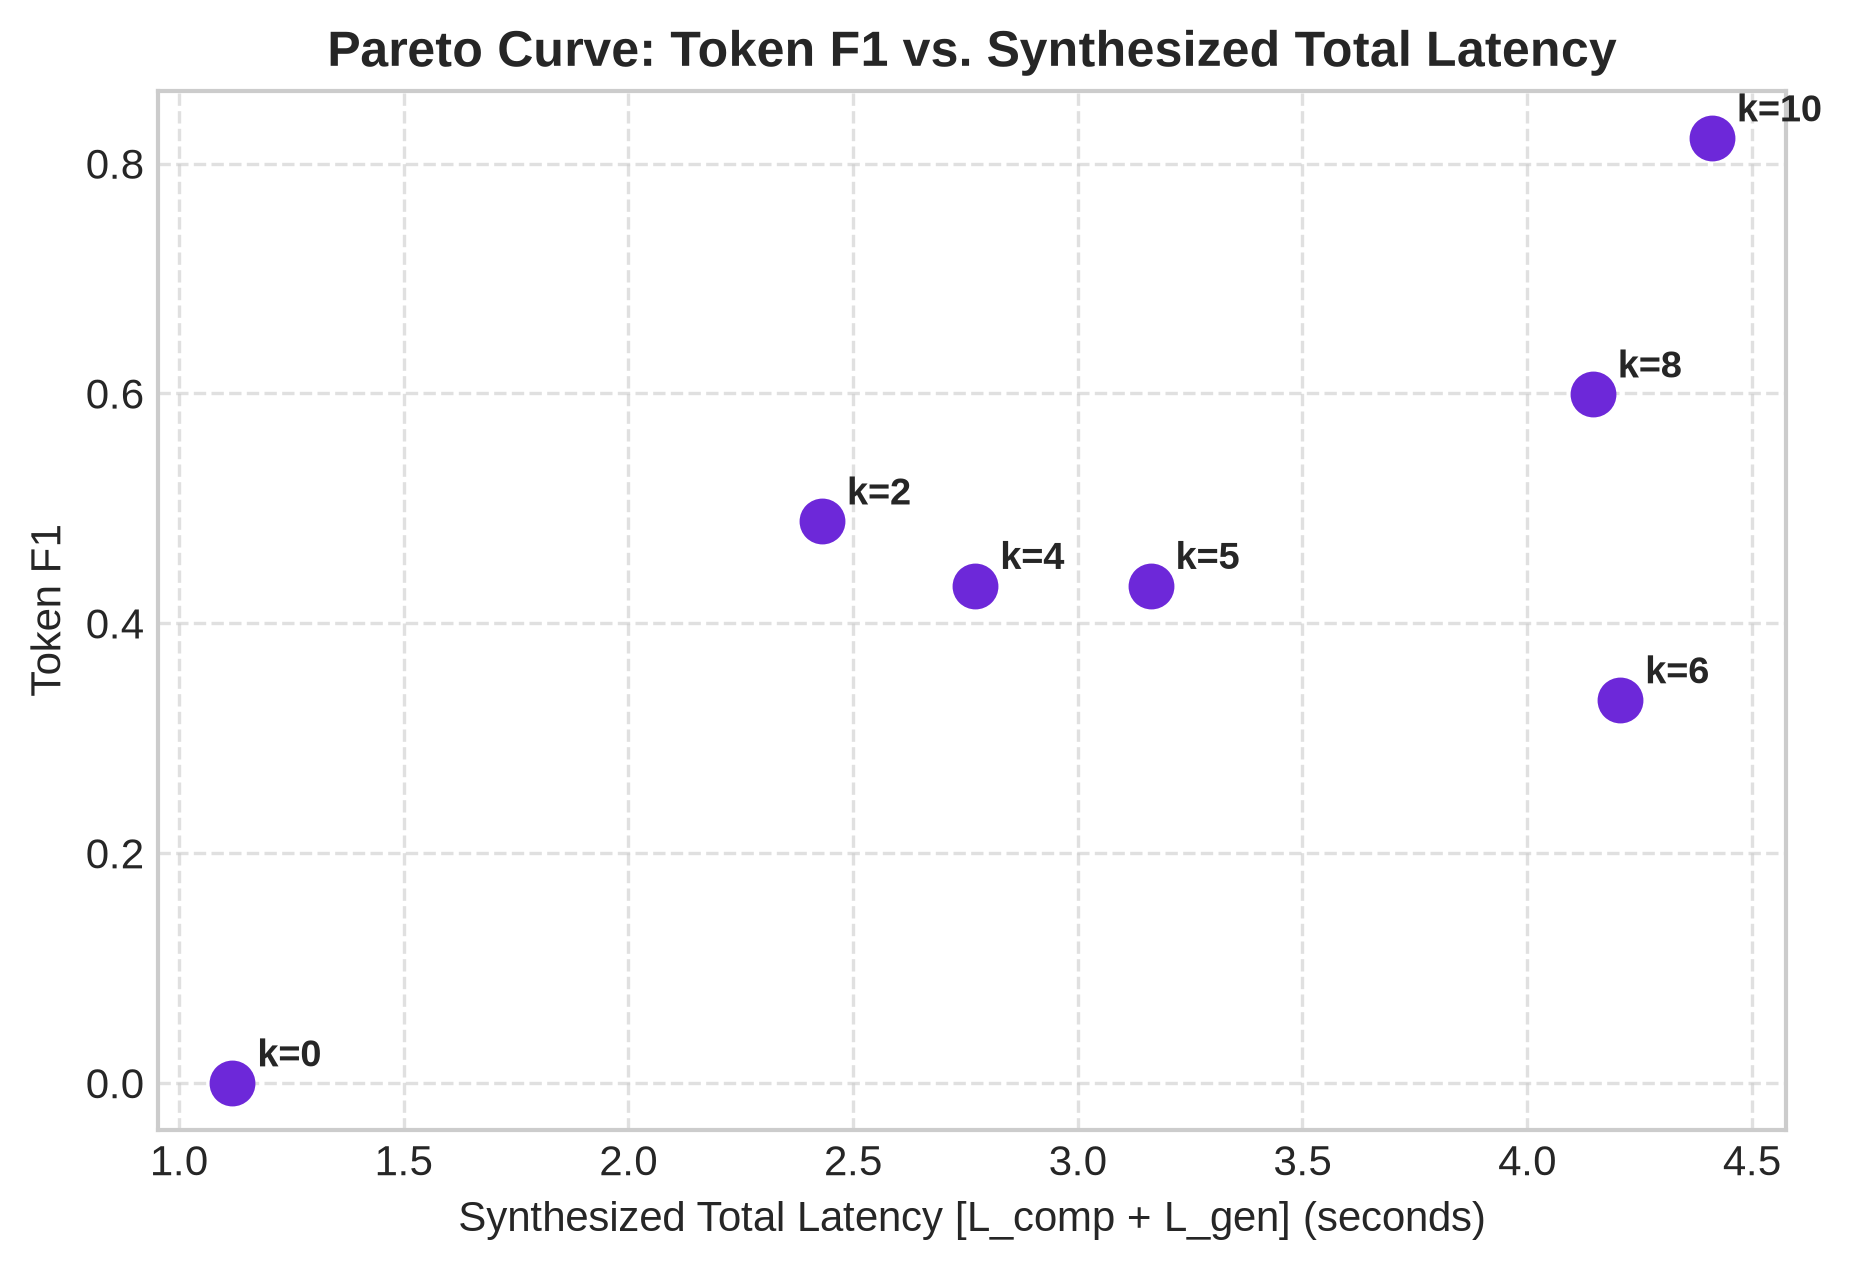


--- Figure: Empirical Distribution of Per-Question Optimal k* (08_per_question_best_k_distribution.png) ---


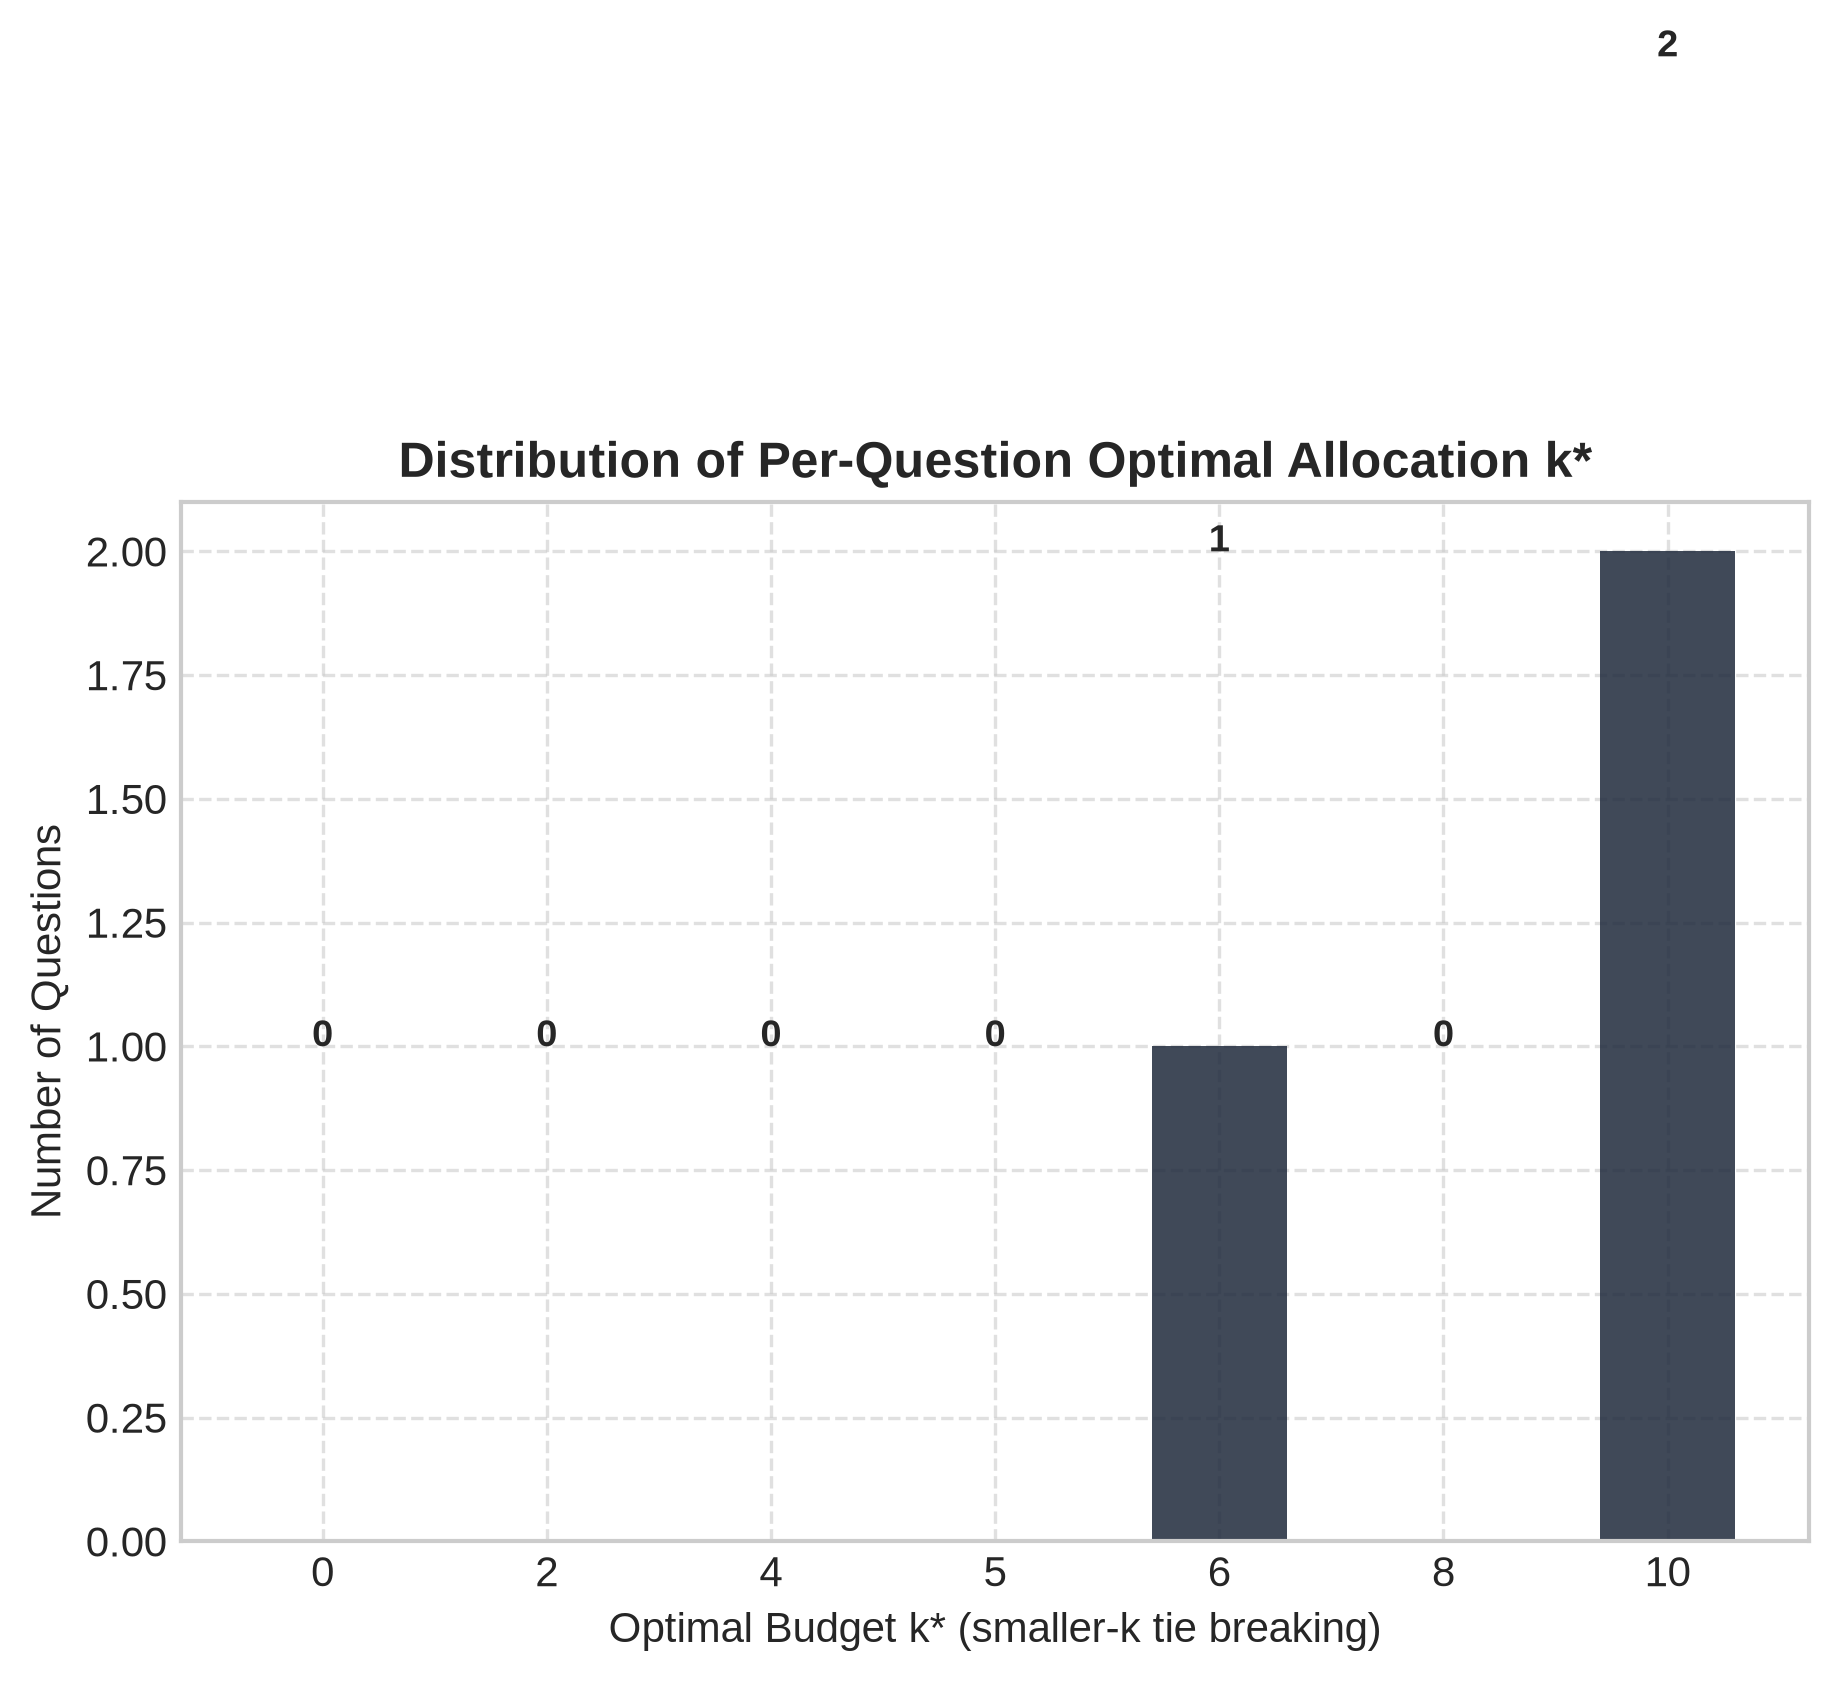

In [11]:
plots_dir = REPO_ROOT / "results" / "week2" / "plots"

plot_files = [
    ("01_mean_token_f1_vs_k.png", "Mean Token-F1 vs Allocation k"),
    ("02_mean_em_vs_k.png", "Mean Exact Match vs Allocation k"),
    ("03_mean_rouge_l_vs_k.png", "Mean ROUGE-L vs Allocation k"),
    ("04_mean_input_tokens_vs_k.png", "Mean Input Context Tokens vs Allocation k"),
    ("05_token_f1_vs_context_tokens.png", "Pareto Curve: Token-F1 vs Context Tokens"),
    ("06_token_f1_vs_generation_latency.png", "Token-F1 vs Measured Generation Latency"),
    ("07_token_f1_vs_synthesized_total_latency.png", "Token-F1 vs Synthesized Total Latency"),
    ("08_per_question_best_k_distribution.png", "Empirical Distribution of Per-Question Optimal k*"),
]

for filename, title in plot_files:
    img_path = plots_dir / filename
    if img_path.exists():
        print(f"\n--- Figure: {title} ({filename}) ---")
        display(Image(filename=str(img_path), width=750))
    else:
        print(f"Figure not found: {img_path}")


## 10. Key Takeaways & Transition to Week 3

1. **Trade-Off Dynamics:**
   - Lower $k$ ($k=0, 2$) drastically cuts prompt context tokens (up to 91% reduction) and generation latency, but full compression $k=0$ loses fine-grained lexical grounding.
   - Intermediate $k$ ($k=4, 5, 6$) retains strong competitive accuracy while saving substantial context tokens relative to $k=10$.
2. **Per-Query Heterogeneity:**
   - The optimal $k^*$ is **not uniform across queries**: high-concentration queries ($ho_1 \approx 1.0$) succeed with small $k$, whereas diffuse queries benefit from higher $k$.
3. **Bridge to Week 3:**
   - The response matrix generated here forms the direct training supervision for the **Week-3 Query-Conditioned Evidence Allocator (QCCA)**, which dynamically predicts the optimal $k^*(q)$ for each individual query.
